# GPU check

In [19]:
import torch

def check_environment():
    if torch.cuda.is_available():
        # 接続されているGPU名を取得
        gpu_name = torch.cuda.get_device_name(0)
        print(f"--- 💡 Execution Environment: GPU ({gpu_name}) ---")
    else:
        print("--- 💡 Execution Environment: CPU ---")

# 文頭で呼び出し
check_environment()

--- 💡 Execution Environment: CPU ---


# Mount drive

In [20]:
check_environment()


from google.colab import drive
drive.mount('/content/drive')


--- 💡 Execution Environment: CPU ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Visualization

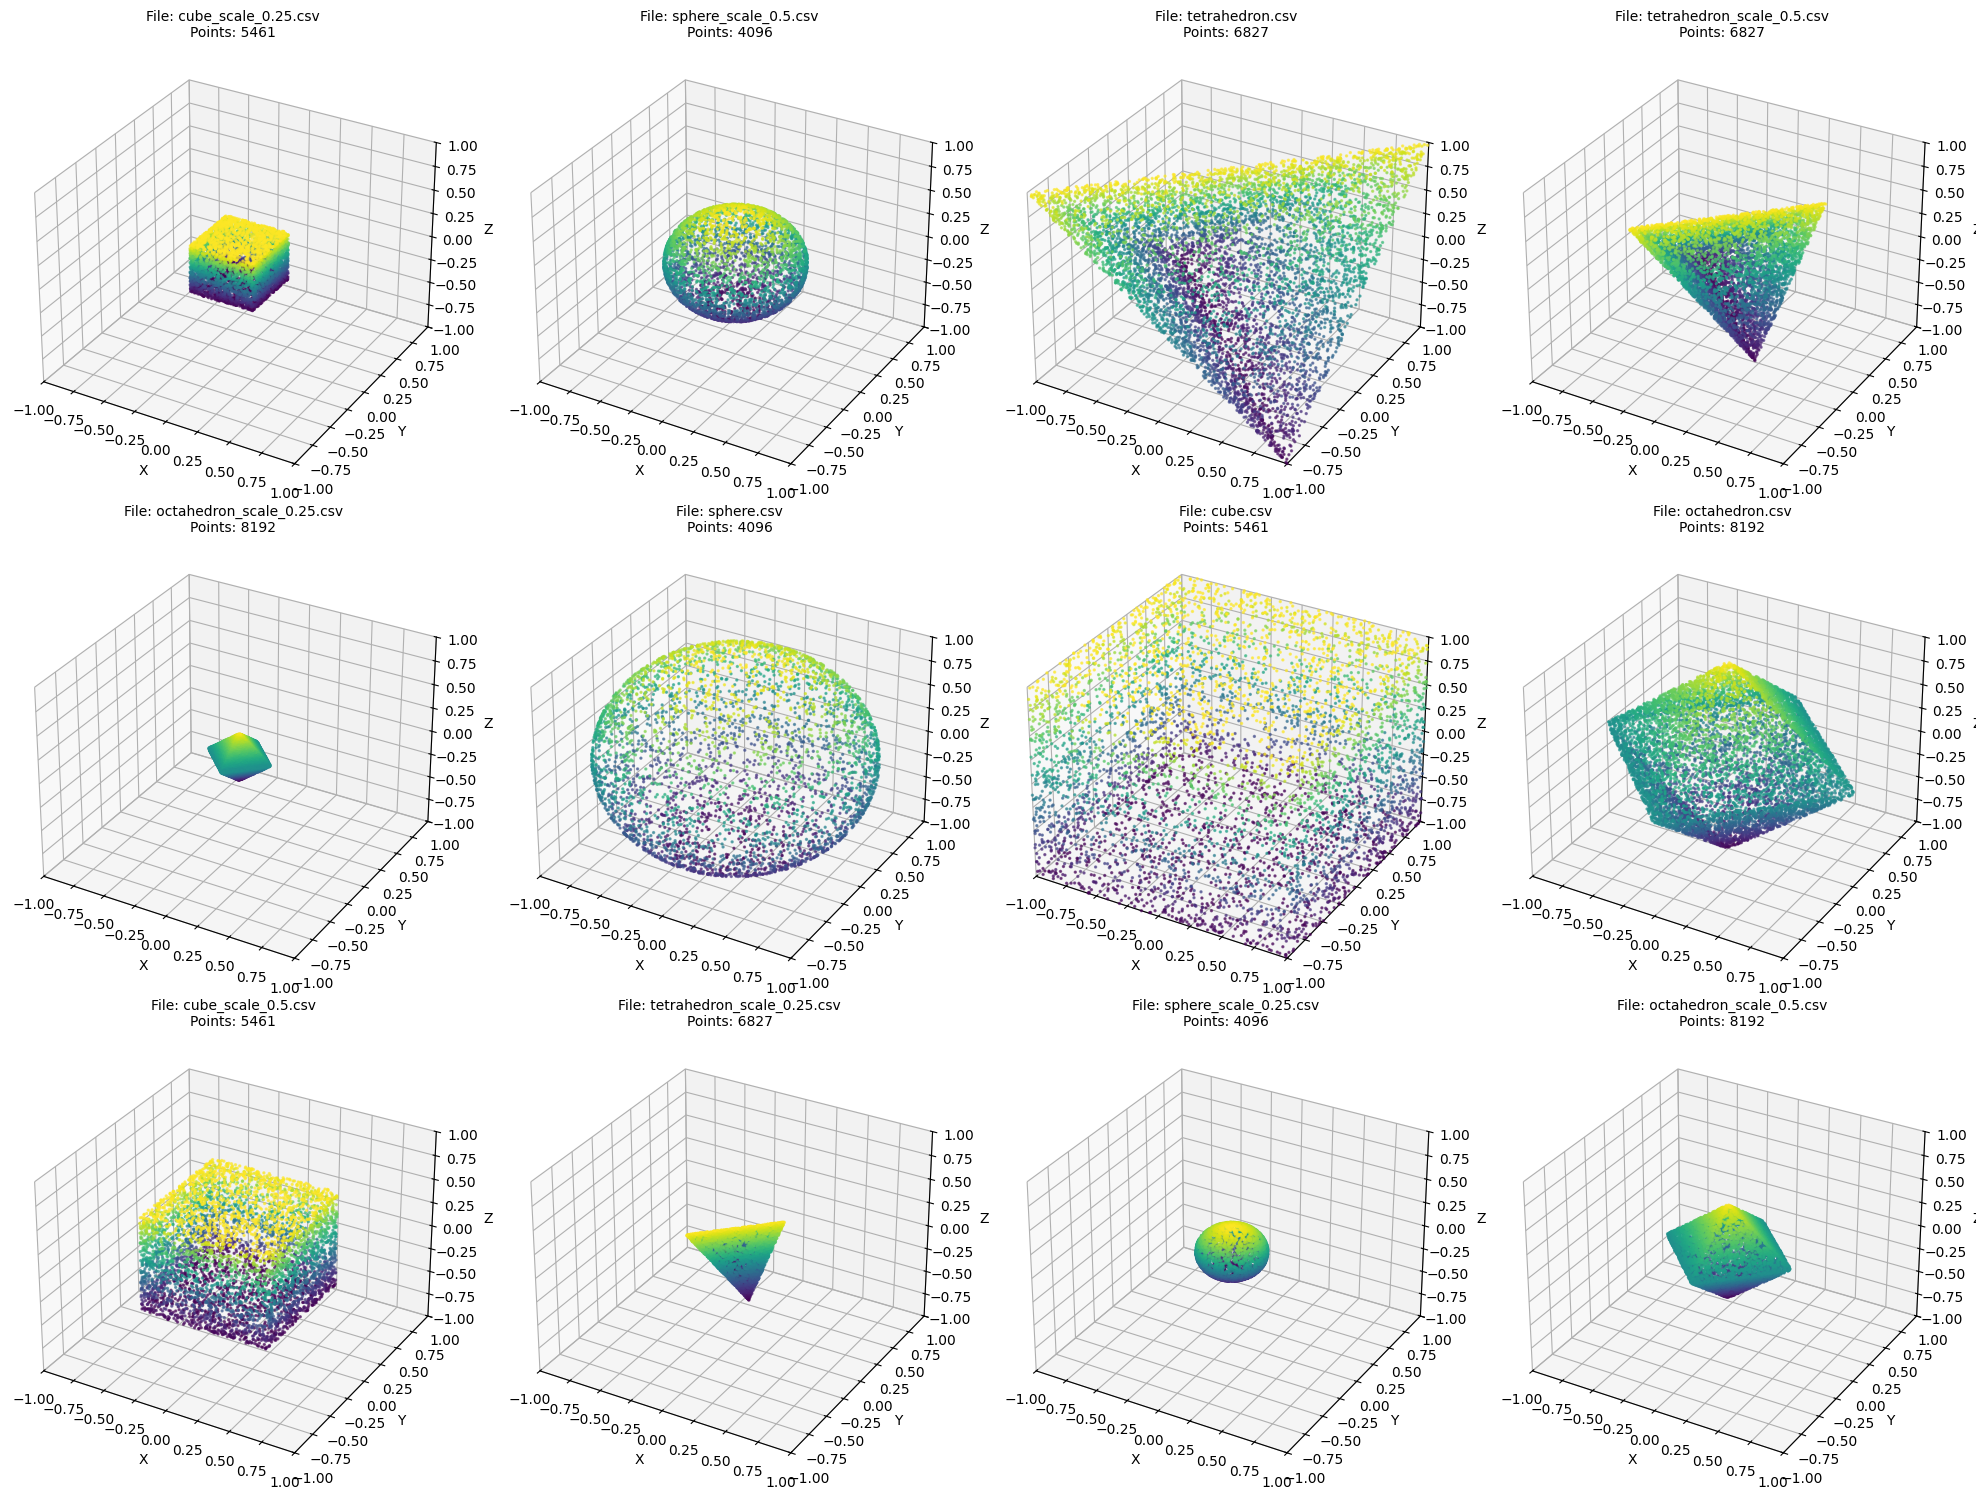

In [21]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt

# 1. パスの設定
folder_path = "/content/drive/MyDrive/output_data_-1_1_vari_point"  # フォルダパス
#folder_path = "/content/drive/MyDrive/Python/VAE_Bolt_loosing/output_data_-1_1"  # フォルダパス

# 2. ファイルリストの取得（.csvのみ）
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# ★ 変更点: ランダムに重複なく12個を選択
# （フォルダ内のCSVが12個未満の場合は、存在する数だけをランダムに選択します）
num_samples = min(12, len(csv_files))
csv_files = random.sample(csv_files, num_samples)

# 3. 可視化の準備 (12個配置するため、3行4列のグラフ領域を作成)
# 全体が収まるように少しサイズを大きく設定しています
fig = plt.figure(figsize=(20, 15))

for i, filename in enumerate(csv_files):
    # ファイルの読み込み
    file_full_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_full_path, header=None)
    
    # 点群数（行数）を取得
    num_points = len(df)
    
    # データが (N, 3) 形式であることを想定
    points = df.values
    
    # 4. サブプロットの追加 (3行4列の i+1 番目)
    ax = fig.add_subplot(3, 4, i + 1, projection='3d')
    
    # 散布図の描画 (c=points[:, 2] で高さに応じた色分け)
    sc = ax.scatter(points[:, 0], points[:, 1], points[:, 2], 
                    c=points[:, 2], cmap='viridis', s=2, alpha=0.6)
    
    # タイトルとラベル
    # ★ ファイル名の後に改行を入れて点群数を表示
    ax.set_title(f"File: {filename}\nPoints: {num_points}", fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    # ★ x, y, zの軸の表示範囲を -1 から 1 に固定
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
#    ax.set_xlim([0, 1])
#    ax.set_ylim([0, 1])
#    ax.set_zlim([0, 1])

# レイアウトの調整
plt.tight_layout()
plt.show()

# VAE

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
import os
import pandas as pd
import random
import numpy as np
import math

# --- 1. エンコーダ・デコーダ・距離関数等の定義 ---
class PointNetEncoder(nn.Module):
    def __init__(self, z_dim=256):
        super().__init__()
        self.z_dim = z_dim
        self.feature_extractor = nn.Sequential(
            self._conv_bn(3, 64),
            self._conv_bn(64, 128),
            self._conv_bn(128, 256),
            self._conv_bn(256, 512),
            self._conv_bn(512, 1024),
        )
        self.fc_mu = nn.Linear(1024, z_dim)
        self.fc_logvar = nn.Linear(1024, z_dim)

    def _conv_bn(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv1d(in_channels, out_channels, 1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(True)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.max(x, dim=2)[0] # (B, 1024)
        return self.fc_mu(x), self.fc_logvar(x)

class MLPDecoder(nn.Module):
    def __init__(self, z_dim=256, num_points=4096):
        super().__init__()
        self.num_points = num_points
        self.model = nn.Sequential(
            nn.Linear(z_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(True),
            nn.Linear(2048, num_points * 3),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.model(z)
        return x.view(-1, self.num_points, 3)


import math

# ==========================================
# ★ 新規追加: ドメイン知識（プラス/マイナス）を強制するLinear層
# ==========================================
class SignConstrainedLinear(nn.Module):
    def __init__(self, in_features, out_features, constraints):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        
        # 制約をテンソルとして保持 (0: フリー, 1: プラス, -1: マイナス)
        self.constraints = torch.tensor(constraints, dtype=torch.float32)

        self.weight_raw = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight_raw, a=math.sqrt(5))
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight_raw)
        bound = 1 / math.sqrt(fan_in)
        nn.init.uniform_(self.bias, -bound, bound)

    def get_effective_weight(self):
        device = self.weight_raw.device
        constraints = self.constraints.to(device)

        w_softplus = F.softplus(self.weight_raw)

        effective_weight = torch.where(
            constraints == 1, w_softplus,
            torch.where(
                constraints == -1, -w_softplus,
                self.weight_raw
            )
        )
        return effective_weight

    def forward(self, x):
        effective_weight = self.get_effective_weight()
        return F.linear(x, effective_weight, self.bias)

# ★ 修正版：OLSの結果から逆算して初期値をセットするメソッド
    def initialize_from_ols(self, ols_weights, ols_bias):
        new_raw = torch.zeros_like(self.weight_raw.data)
        
        for i in range(self.in_features):
            c = self.constraints[i].item()
            
            # ★ ここを修正！: numpy.float32 を Pythonの標準 float に変換
            val = float(ols_weights[i])

            if c == 1: # 必ずプラスの制約
                # もしOLSの結果がマイナスなら、微小なプラス(1e-4)に強制妥協させる
                val = max(val, 1e-4) 
                # 逆Softplusの計算: raw = log(exp(val) - 1)
                new_raw[0, i] = math.log(math.expm1(val)) if val < 20 else val
                
            elif c == -1: # 必ずマイナスの制約
                # もしOLSの結果がプラスなら、微小なマイナス(-1e-4)に強制妥協させる
                val = min(val, -1e-4)
                val_pos = -val # 計算用に一旦正の数にする
                new_raw[0, i] = math.log(math.expm1(val_pos)) if val_pos < 20 else val_pos
                
            else: # フリー (制約なし)
                new_raw[0, i] = val

        # パラメータを安全に上書き
        self.weight_raw.data.copy_(new_raw)
        self.bias.data.fill_(float(ols_bias))
        
# ==========================================
# ★ 改修: PointCloudVAE (制約リストを受け取るように変更)
# ==========================================
class PointCloudVAE(nn.Module):
    def __init__(self, z_dim=3, num_points=4096, num_ext_features1=3, num_ext_features2=4,
                 ext_constraints1=None, ext_constraints2=None):
        super().__init__()
        self.encoder = PointNetEncoder(z_dim)
        self.decoder = MLPDecoder(z_dim, num_points)
        
        # Task1の制約リストを作成 (指定がなければ全て0=フリー)
        if ext_constraints1 is None:
            ext_constraints1 = [0] * num_ext_features1
        # z_dim分は制約なし(0)とし、その後ろに外部特徴量の制約を繋げる
        full_constraints1 = [0] * z_dim + ext_constraints1
        
        # Task2の制約リストを作成
        if ext_constraints2 is None:
            ext_constraints2 = [0] * num_ext_features2
        full_constraints2 = [0] * z_dim + ext_constraints2

        # 変更: nn.Linear から SignConstrainedLinear へ
        self.regressor1 = SignConstrainedLinear(z_dim + num_ext_features1, 1, full_constraints1)
        self.regressor2 = SignConstrainedLinear(z_dim + num_ext_features2, 1, full_constraints2)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

    def predict_task1(self, mu, ext_features):
        reg_input = torch.cat([mu, ext_features], dim=1)
        return self.regressor1(reg_input)

    def predict_task2(self, mu, ext_features):
        reg_input = torch.cat([mu, ext_features], dim=1)
        return self.regressor2(reg_input)
    

# ★ 変更点: CD関数のみ、サンプリングと重み付け(p_factor)付きの高度なバージョンを維持
def chamfer_distance(p1, p2, num_samples=4096, p_factor=1.0):
    """
    p1, p2 shape: (Batch_size, Num_points, 3)
    p_factor: 大きなズレ（形状の違い）を指数関数的に重く罰するための係数
    """
    # サンプリングによる計算量の削減
    if p1.size(1) > num_samples:
        indices1 = torch.randperm(p1.size(1), device=p1.device)[:num_samples]
        p1 = p1[:, indices1, :]
        
    if p2.size(1) > num_samples:
        indices2 = torch.randperm(p2.size(1), device=p2.device)[:num_samples]
        p2 = p2[:, indices2, :]

    # 距離行列の計算
    p1_norm = torch.sum(p1**2, dim=2, keepdim=True) 
    p2_norm = torch.sum(p2**2, dim=2, keepdim=True).transpose(1, 2)
    dist_matrix = p1_norm + p2_norm - 2 * torch.bmm(p1, p2.transpose(1, 2))
    dist_matrix = torch.clamp(dist_matrix, min=0.0)
    
    # 各点からの最小距離を取得
    dist_p1_p2 = torch.min(dist_matrix, dim=2)[0]
    dist_p2_p1 = torch.min(dist_matrix, dim=1)[0]
    
    # 重み付け（べき乗）して合計
    loss_p1_p2 = torch.pow(dist_p1_p2, p_factor).sum(dim=1).mean()
    loss_p2_p1 = torch.pow(dist_p2_p1, p_factor).sum(dim=1).mean()
    
    return loss_p1_p2 + loss_p2_p1

# Dataset

In [23]:
check_environment()


import matplotlib.pyplot as plt
from IPython.display import clear_output
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
import os
import pandas as pd
import random
import numpy as np
import datetime
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- 2. カスタムデータセット ---
def pointcloud_collate_fn(batch):
    filenames = [item[0] for item in batch]
    # ★ 変更: 長さがバラバラなので、ここでは stack せずにリストのまま返す
    points = [item[1] for item in batch] 
    ext_features1 = [item[2] for item in batch]
    targets1 = [item[3] for item in batch]
    ext_features2 = [item[4] for item in batch]
    targets2 = [item[5] for item in batch]
    return filenames, points, ext_features1, targets1, ext_features2, targets2

class PointCloudCSVDataset(Dataset):
    def __init__(self, folder_path, meta_csv_path1, meta_csv_path2, num_ext_features1=3, num_ext_features2=4, max_points=4096):
        self.filename_list = [] 
        self.points_list = []
        self.ext_features1_list = []
        self.targets1_list = []
        self.ext_features2_list = []
        self.targets2_list = []
        
        self.scalers = {}


# PointCloudCSVDataset クラス内の一部を抜粋・変更
    def __init__(self, folder_path, meta_csv_path1, meta_csv_path2, num_ext_features1=3, num_ext_features2=4, max_points=4096):
        self.filename_list = [] 
        self.points_list = []
        self.ext_features1_list = []
        self.targets1_list = []
        self.ext_features2_list = []
        self.targets2_list = []
        
        # ★ 追加: VAEに渡すための制約リストを保持する変数
        self.constraints1 = []
        self.constraints2 = []

        def load_meta(csv_path, num_features, task_name):
            # ★ 変更: 最初は全て文字列(dtype=str)として読み込む
            raw_df = pd.read_csv(csv_path, encoding="cp932", dtype=str)
            
            # 1. 制約行（データとしての1行目 = index 0）の抽出とリスト化
            constraint_row = raw_df.iloc[0]
            constraints = []
            for i in range(2, 2 + num_features):
                val = str(constraint_row.iloc[i]).strip().lower()
                if val == 'positive':
                    constraints.append(1)
                elif val == 'negative':
                    constraints.append(-1)
                else:
                    constraints.append(0) # freeや空欄は制約なし(0)
            
            # 2. クラス変数に保存
            if task_name == "task1":
                self.constraints1 = constraints
            else:
                self.constraints2 = constraints
                
            # 3. 制約行を削除し、純粋なデータ行だけのDataFrameを作成
            meta_df = raw_df.iloc[1:].copy()
            meta_df.reset_index(drop=True, inplace=True) # インデックスを振り直す
            
            # ターゲットと特徴量の列を数値型(float32)に変換
            target_col = meta_df.columns[1]
            meta_df[target_col] = meta_df[target_col].astype(np.float32)
            for i in range(2, 2 + num_features):
                feat_col = meta_df.columns[i]
                meta_df[feat_col] = meta_df[feat_col].astype(np.float32)

            orig_df = meta_df.copy() # 標準化前の元の値を保持
            
            # --- 以降は元の標準化処理をそのまま適用 ---
            # 1. 目的変数（ターゲット）の標準化
            t_mean = meta_df[target_col].mean()
            t_std = meta_df[target_col].std()
            meta_df[target_col] = (meta_df[target_col] - t_mean) / (t_std + 1e-8)
            
            # 2. 説明変数（特徴量）の標準化
            for i in range(2, 2 + num_features):
                feat_col = meta_df.columns[i]
                f_mean = meta_df[feat_col].mean()
                f_std = meta_df[feat_col].std()
                meta_df[feat_col] = (meta_df[feat_col] - f_mean) / (f_std + 1e-8)

            meta_dict = {}
            for idx, row in meta_df.iterrows():
                orig_row = orig_df.iloc[idx] # 対応する元の行データ
                filename = str(row.iloc[0])
                
                # 標準化後の値
                target = [row[target_col]] 
                features = row.iloc[2 : 2 + num_features].values.astype(np.float32)
                
                # 標準化前の元の値
                orig_target = [orig_row[target_col]]
                orig_features = orig_row.iloc[2 : 2 + num_features].values.astype(np.float32)
                
                if filename not in meta_dict:
                    meta_dict[filename] = []
                meta_dict[filename].append((features, target, orig_features, orig_target))
                
            return meta_dict

        # ★変更点: 評価時に呼び出せるように self.meta_dict としてクラス変数に保持
        self.meta_dict1 = load_meta(meta_csv_path1, num_features=num_ext_features1, task_name="task1")
        self.meta_dict2 = load_meta(meta_csv_path2, num_features=num_ext_features2, task_name="task2")

        if not os.path.exists(folder_path):
            print(f"Warning: {folder_path} not found.")
            return

        csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

        for filename in csv_files:
            # 【削除】以前ここにあった「メタデータになければ continue」というスキップ処理を削除します
            # if filename not in self.meta_dict1 or filename not in self.meta_dict2:
            #     continue 
                
            df = pd.read_csv(os.path.join(folder_path, filename), header=None, dtype=np.float32, encoding="cp932")
            pts = df.values
            
            # max_points 未満のデータは除外するが、ダウンサンプリング（切り捨て）はしない
            if len(pts) >= max_points:
                self.filename_list.append(filename) 
                self.points_list.append(torch.from_numpy(pts).t())
                
                # ==========================================
                # ★ 変更: Task1メタデータの有無で分岐 (NaNマスキング)
                # ==========================================
                if filename in self.meta_dict1:
                    feats1, tgts1, _, _ = zip(*self.meta_dict1[filename])
                    self.ext_features1_list.append(torch.tensor(np.array(feats1), dtype=torch.float32))
                    self.targets1_list.append(torch.tensor(np.array(tgts1), dtype=torch.float32))
                else:
                    # メタデータがない場合は NaN で埋めたダミーテンソルを作成
                    self.ext_features1_list.append(torch.full((1, num_ext_features1), float('nan')))
                    self.targets1_list.append(torch.full((1, 1), float('nan')))

                # ==========================================
                # ★ 変更: Task2メタデータの有無で分岐 (NaNマスキング)
                # ==========================================
                if filename in self.meta_dict2:
                    feats2, tgts2, _, _ = zip(*self.meta_dict2[filename])
                    self.ext_features2_list.append(torch.tensor(np.array(feats2), dtype=torch.float32))
                    self.targets2_list.append(torch.tensor(np.array(tgts2), dtype=torch.float32))
                else:
                    self.ext_features2_list.append(torch.full((1, num_ext_features2), float('nan')))
                    self.targets2_list.append(torch.full((1, 1), float('nan')))

    def __len__(self):
        return len(self.points_list)

    def __getitem__(self, idx):
        return (self.filename_list[idx],
                self.points_list[idx], 
                self.ext_features1_list[idx], self.targets1_list[idx],
                self.ext_features2_list[idx], self.targets2_list[idx])


--- 💡 Execution Environment: CPU ---


# Data Manage

In [24]:
check_environment()

# --- 3. 学習マネージャー ---
class PointCloudTrainer:
    def __init__(self, model, lr=1e-4, device="cuda" if torch.cuda.is_available() else "cpu"):
        self.device = torch.device(device)
        self.model = model.to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == "cuda"))
        
    # ★追加：引数に cd_num_samples=4096 を追加
    def train_epoch(self, dataloader, epoch, pts_warmup_epochs, kl_warmup_epochs, 
                    reg_warmup_start_epoch, reg_warmup_epochs, 
                    start_points=1024, max_points=4096, cd_num_samples=4096, 
                    gamma=1.0, kl_weight=3.0, use_task1=True, use_task2=True):
        torch.set_grad_enabled(True) 
        self.model.train()
        
        for param in self.model.parameters():
            param.requires_grad = True

        total_loss, total_recon, total_kl = 0, 0, 0
        total_mse1, total_mse2, total_r2_1, total_r2_2 = 0, 0, 0, 0
        
        epoch_mu_list = []
        
        # 1. ポイント数のウォームアップ
        alpha_pts = min(1.0, epoch / max(1, pts_warmup_epochs))
        curr_points = int(start_points + (max_points - start_points) * alpha_pts)
        curr_points = (curr_points // 32) * 32 
        
        # 2. KLロスのウォームアップ
        alpha_kl = min(1.0, epoch / max(1, kl_warmup_epochs))
        start_beta = 0.01
        max_beta = 1.0
        beta = start_beta + (max_beta - start_beta) * alpha_kl
        
        # 3. 回帰ロス(MSE)のウォームアップ（開始エポック遅延対応）
        if epoch < reg_warmup_start_epoch:
            alpha_reg = 0.0
        else:
            effective_epoch = epoch - reg_warmup_start_epoch
            alpha_reg = min(1.0, effective_epoch / max(1, reg_warmup_epochs))
            
        current_gamma = gamma * alpha_reg
        
        for batch in dataloader:
            filenames, points, ext_features1_list, targets1_list, ext_features2_list, targets2_list = batch
            points = points.to(self.device)
            
            self.optimizer.zero_grad()
            
            with torch.cuda.amp.autocast(enabled=(self.device.type == "cuda")):
                reconstructed, mu, logvar = self.model(points)
                
                epoch_mu_list.append(mu.detach().cpu())
                
                target_pts = points.transpose(1, 2)[:, :curr_points, :]
                pred_pts = reconstructed[:, :curr_points, :]
                
                # ★変更：chamfer_distance に num_samples 引数として渡す
                recon_loss = chamfer_distance(pred_pts, target_pts, num_samples=cd_num_samples)
                kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
                
                def calc_r2(targets, preds):
                    ss_res = torch.sum((targets - preds) ** 2)
                    ss_tot = torch.sum((targets - torch.mean(targets)) ** 2)
                    return 1 - ss_res / (ss_tot + 1e-8)

                # ==========================================
                # (ここから train_epoch 内の変更部分)
                # ==========================================
                if use_task1:
                    mu_expanded1, feats1_cat, targets1_cat = [], [], []
                    for i in range(len(mu)):
                        num_items = ext_features1_list[i].shape[0] 
                        mu_expanded1.append(mu[i].unsqueeze(0).expand(num_items, -1))
                        feats1_cat.append(ext_features1_list[i].to(self.device))
                        targets1_cat.append(targets1_list[i].to(self.device))
                    
                    mu_expanded1 = torch.cat(mu_expanded1, dim=0)
                    feats1_cat = torch.cat(feats1_cat, dim=0)
                    targets1_cat = torch.cat(targets1_cat, dim=0)
                    
                    # ★ 追加: NaNをフィルタリングするマスクを作成
                    valid_mask1 = ~torch.isnan(targets1_cat[:, 0])
                    
                    if valid_mask1.sum() > 0: # バッチ内に1つでも有効なデータがあれば計算
                        valid_mu1 = mu_expanded1[valid_mask1]
                        valid_feats1 = feats1_cat[valid_mask1]
                        valid_targets1 = targets1_cat[valid_mask1]
                        
                        pred_targets1 = self.model.predict_task1(valid_mu1, valid_feats1)
                        mse_loss1 = F.mse_loss(pred_targets1, valid_targets1)
                        r2_1 = calc_r2(valid_targets1, pred_targets1)
                    else:
                        mse_loss1 = torch.tensor(0.0, device=self.device)
                        r2_1 = torch.tensor(0.0, device=self.device)
                else:
                    mse_loss1 = torch.tensor(0.0, device=self.device)
                    r2_1 = torch.tensor(0.0, device=self.device)

                if use_task2:
                    mu_expanded2, feats2_cat, targets2_cat = [], [], []
                    for i in range(len(mu)):
                        num_items = ext_features2_list[i].shape[0]
                        mu_expanded2.append(mu[i].unsqueeze(0).expand(num_items, -1))
                        feats2_cat.append(ext_features2_list[i].to(self.device))
                        targets2_cat.append(targets2_list[i].to(self.device))
                    
                    mu_expanded2 = torch.cat(mu_expanded2, dim=0)
                    feats2_cat = torch.cat(feats2_cat, dim=0)
                    targets2_cat = torch.cat(targets2_cat, dim=0)
                    
                    # ★ 追加: マスキング
                    valid_mask2 = ~torch.isnan(targets2_cat[:, 0])
                    
                    if valid_mask2.sum() > 0:
                        valid_mu2 = mu_expanded2[valid_mask2]
                        valid_feats2 = feats2_cat[valid_mask2]
                        valid_targets2 = targets2_cat[valid_mask2]
                        
                        pred_targets2 = self.model.predict_task2(valid_mu2, valid_feats2)
                        mse_loss2 = F.mse_loss(pred_targets2, valid_targets2)
                        r2_2 = calc_r2(valid_targets2, pred_targets2)
                    else:
                        mse_loss2 = torch.tensor(0.0, device=self.device)
                        r2_2 = torch.tensor(0.0, device=self.device)
                else:
                    mse_loss2 = torch.tensor(0.0, device=self.device)
                    r2_2 = torch.tensor(0.0, device=self.device)
                    
                total_mse_loss = mse_loss1 + mse_loss2
                
                loss = 1.0 * recon_loss + kl_weight * beta * kl_loss + current_gamma * total_mse_loss
            
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
            
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            total_mse1 += mse_loss1.item()
            total_mse2 += mse_loss2.item()
            total_r2_1 += r2_1.item()
            total_r2_2 += r2_2.item()
            
        n_batches = len(dataloader)
        
        all_mu_np = torch.cat(epoch_mu_list, dim=0).numpy()
        mu_stats = {
            'max': float(np.max(all_mu_np)),
            'min': float(np.min(all_mu_np)),
            'mean': float(np.mean(all_mu_np)),
            'median': float(np.median(all_mu_np)),
            'std': float(np.std(all_mu_np))
        }
        
        return (total_loss / n_batches, total_recon / n_batches, total_kl / n_batches, 
                total_mse1 / n_batches, total_mse2 / n_batches, 
                total_r2_1 / n_batches, total_r2_2 / n_batches, 
                beta, current_gamma, curr_points, mu_stats)

--- 💡 Execution Environment: CPU ---


# Train


[Dataset Loading Summary]
Total Point Cloud Files Loaded : 12 files (Unique Shapes)
----------------------------------------
 [Task 1]
  -> Valid Shape Files  : 11 / 12 files
  -> Total Meta Samples : 13 rows (Regression Data)
----------------------------------------
 [Task 2]
  -> Valid Shape Files  : 12 / 12 files
  -> Total Meta Samples : 15 rows (Regression Data)

[WARMUP] Epoch [   1/1] Pts: 4096 | Loss: 426.5244 | Recon: 425.9707 | KL:  18.4561 | Task1 -> NN_MSE: 60762.4648, NN_R2: -65824.9922 | Task2 -> NN_MSE: 978599.4375, NN_R2: -1048498.3125
      Latent(mu) Stats -> Max:  6.046 | Min: -4.875 | Mean: -0.582 | Median: -0.442 | Std:  1.660

      [Constrained Neural Network Regression (Effective Weights)]
      Task1 NN -> R2: -65824.9922 | Latent(mu) Coefs: [-58.9587, 338.7559, 155.8709, -14.8272, -162.3516, 15.7423, 36.6352, 222.9208] | ExtFeatures: [-0.0217, -0.8307, 0.2411] | Bias: -4.0617
      Task2 NN -> R2: -1048498.3125 | Latent(mu) Coefs: [227.6691, -2285.5505, 783.6

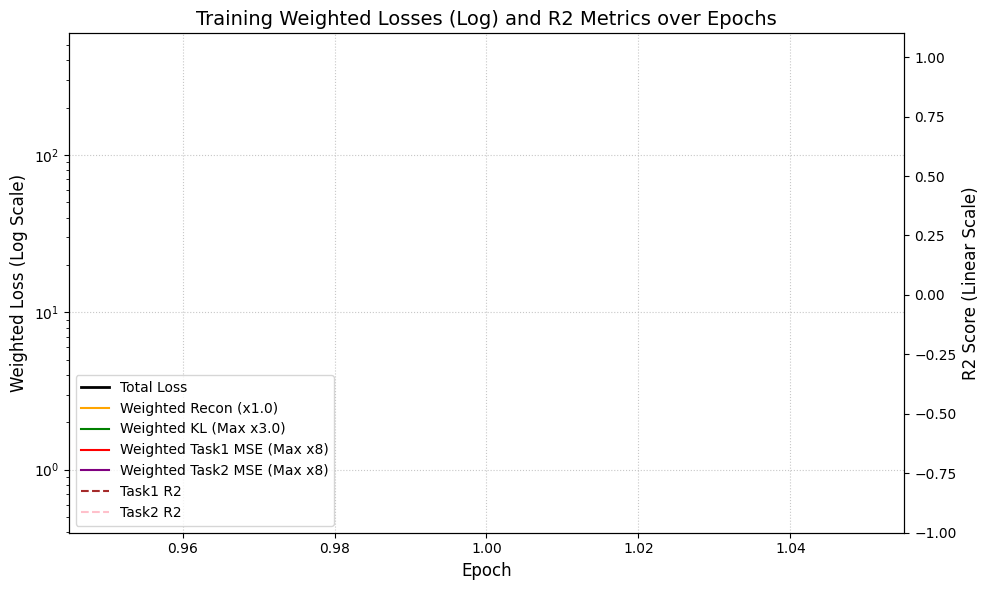

In [ ]:
check_environment()



# --- 4. メイン実行 ---
# ==========================================
# ★ 汎用スイッチ設定 ★
use_task1 = True
use_task2 = True

# ★ 追加：重みのロードスイッチ
use_pretrained = True#False#  # True: ファインチューニング(重み読込), False: ゼロから学習
pretrained_model_path = "/content/drive/MyDrive/Results/vae_model_weights_20260314_224418.pth"
# ==========================================

# ==========================================
# ★ ハイパーパラメータとウォームアップ設定 ★
z_dim = 3 
num_points = 4096#4576

# ★追加：CD(Chamfer Distance)計算時にサンプリングする点群数
cd_num_samples = 4096#4756

# ★追加：ウォームアップ開始時の点群数（ここで指定可能にしました）
start_points = 4096#4576 

# ★変更：バッチサイズを 4 にして学習の「揺らぎ」を作ります
batch_size = 12#23  
num_epochs = 1#1000#10000#1500#2000#5000 2000はテスト値
lr = 1e-5#3e-5

# 独立したウォームアップ期間の設定
pts_warmup_epochs = 0#4000
kl_warmup_epochs = 0#4000

# 回帰ウォームアップの開始エポックを指定
reg_warmup_start_epoch = 0#10001#500
reg_warmup_epochs = num_epochs - reg_warmup_start_epoch

# 最終的な重みの設定
kl_weight = 3.0
gamma = 8
# ==========================================

num_ext_features1 = 3
num_ext_features2 = 4

fig_size = (10, 6)

# パスの設定
meta_csv_path1 = "/content/drive/MyDrive/meta_data/meta_data_update1_ver4_test.csv"
#meta_csv_path1 = "/content/drive/MyDrive/meta_data/meta_data_update1_ver3.csv"
meta_csv_path2 = "/content/drive/MyDrive/meta_data/meta_data_update2_ver3.csv"
#meta_csv_path1 = "/content/drive/MyDrive/Python/VAE_Bolt_loosing/meta_data/meta_data_update1.csv"
#meta_csv_path2 = "/content/drive/MyDrive/Python/VAE_Bolt_loosing/meta_data/meta_data_update2.csv"

# ダミーパスの設定
actual_meta_path1 = meta_csv_path1
actual_ext_feat1 = num_ext_features1
actual_meta_path2 = meta_csv_path2 if use_task2 else actual_meta_path1
actual_ext_feat2 = num_ext_features2 if use_task2 else actual_ext_feat1

# --- 4. メイン実行 ---
# (前略：ハイパーパラメータ等の設定はそのまま)

# 準備
dataset = PointCloudCSVDataset(
    folder_path, 
    actual_meta_path1, 
    actual_meta_path2, 
    num_ext_features1=actual_ext_feat1, 
    num_ext_features2=actual_ext_feat2, 
    max_points=num_points
)

# ★ 追加: データセットが読み込んだ制約リストを取得
constraints_task1 = dataset.constraints1
constraints_task2 = dataset.constraints2

print("Task1 Constraints:", constraints_task1)
print("Task2 Constraints:", constraints_task2)

# ==========================================
# ★ 追加・修正: データセットの読み込み状況（サニティチェック）の表示と保持
# ==========================================
total_files = len(dataset.filename_list)
task1_valid_files = sum(1 for f in dataset.filename_list if f in dataset.meta_dict1)
task2_valid_files = sum(1 for f in dataset.filename_list if f in dataset.meta_dict2)

task1_total_samples = sum(len(dataset.meta_dict1[f]) for f in dataset.filename_list if f in dataset.meta_dict1) if use_task1 else 0
task2_total_samples = sum(len(dataset.meta_dict2[f]) for f in dataset.filename_list if f in dataset.meta_dict2) if use_task2 else 0

# 毎回再表示できるように、文字列として変数(summary_str)に結合して保存する
summary_str = "\n" + "="*50 + "\n"
summary_str += "[Dataset Loading Summary]\n"
summary_str += f"Total Point Cloud Files Loaded : {total_files} files (Unique Shapes)\n"

if use_task1:
    summary_str += "-" * 40 + "\n"
    summary_str += f" [Task 1]\n"
    summary_str += f"  -> Valid Shape Files  : {task1_valid_files} / {total_files} files\n"
    summary_str += f"  -> Total Meta Samples : {task1_total_samples} rows (Regression Data)\n"

if use_task2:
    summary_str += "-" * 40 + "\n"
    summary_str += f" [Task 2]\n"
    summary_str += f"  -> Valid Shape Files  : {task2_valid_files} / {total_files} files\n"
    summary_str += f"  -> Total Meta Samples : {task2_total_samples} rows (Regression Data)\n"
summary_str += "="*50 + "\n"

# 学習前にも一度表示しておく
print(summary_str)
# ==========================================

vae = PointCloudVAE(
    z_dim=z_dim, 
    num_points=num_points, 
    num_ext_features1=actual_ext_feat1, 
    num_ext_features2=actual_ext_feat2,
    ext_constraints1=constraints_task1,
    ext_constraints2=constraints_task2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae.to(device) # 先にデバイスに送る

# ==========================================
# ★ 修正: スイッチに応じた重みのロード処理
# ==========================================
if use_pretrained:
    if os.path.exists(pretrained_model_path):
        vae.load_state_dict(torch.load(pretrained_model_path, map_location=device))
        print(f"[Info] ファインチューニング: {pretrained_model_path} から重みをロードしました。")
    else:
        print(f"[Warning] 指定された重みファイルが見つかりません。ゼロから学習を開始します。")
else:
    print("[Info] ゼロから学習を開始します (ランダム初期化)。")
# ==========================================

trainer = PointCloudTrainer(vae, lr=lr)

# ==========================================
# ★ 改良版 In-Memory化：全データをGPUに乗せる ★
# ==========================================
print("Loading all data to GPU memory...")


full_dataloader = DataLoader(
    dataset, batch_size=len(dataset), shuffle=False, collate_fn=pointcloud_collate_fn
)
all_data_tuple = next(iter(full_dataloader))

gpu_data = []
for item in all_data_tuple:
    # リストの中身がテンソルの場合（点群や特徴量など）
    if isinstance(item, list) and len(item) > 0 and isinstance(item[0], torch.Tensor):
        gpu_data.append([t.to(device) for t in item])
    elif isinstance(item, torch.Tensor):
        gpu_data.append(item.to(device))
    else:
        gpu_data.append(item)

print("Data loaded to GPU successfully!")

# ==========================================
# ★ 新規追加: 循環円サンプラー（Circular Queue Sampler）
# ==========================================
class CircularPointCloudSampler:
    def __init__(self, points_list, max_points, device):
        self.points_list = points_list
        self.max_points = max_points
        self.device = device
        self.num_files = len(points_list)
        self.pointers = [0] * self.num_files
        # 各ファイルに対して、最初のランダムシャッフル順序を生成
        self.perms = [torch.randperm(pts.size(1), device=device) for pts in points_list]

    def sample(self, idx):
        pts = self.points_list[idx]
        N = pts.size(1)
        perm = self.perms[idx]
        ptr = self.pointers[idx]

        if ptr + self.max_points <= N:
            # 1巡目の途中: 規定数をそのまま切り出す
            indices = perm[ptr : ptr + self.max_points]
            self.pointers[idx] += self.max_points
            return pts[:, indices]
        else:
            # 終端に到達: 残りを取り出し、シャッフルして2巡目から不足分を補う
            rem = N - ptr
            indices_part1 = perm[ptr:]
            
            new_perm = torch.randperm(N, device=self.device)
            self.perms[idx] = new_perm
            missing = self.max_points - rem
            indices_part2 = new_perm[:missing]
            self.pointers[idx] = missing
            
            return torch.cat([pts[:, indices_part1], pts[:, indices_part2]], dim=1)

# サンプラーの初期化
sampler = CircularPointCloudSampler(gpu_data[1], num_points, device)

def get_shuffled_in_memory_batches(gpu_data_tuple, batch_size, sampler):
    num_samples = len(gpu_data_tuple[0]) 
    indices = torch.randperm(num_samples, device=device)
    batches = []
    
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx].tolist()
        
        batch_filenames = [gpu_data_tuple[0][i] for i in batch_indices]
        # ★ ここでサンプラーを使って動的に切り出し、stackして1つのテンソルにする
        batch_points = torch.stack([sampler.sample(i) for i in batch_indices], dim=0)
        batch_ext1 = [gpu_data_tuple[2][i] for i in batch_indices]
        batch_tgt1 = [gpu_data_tuple[3][i] for i in batch_indices]
        batch_ext2 = [gpu_data_tuple[4][i] for i in batch_indices]
        batch_tgt2 = [gpu_data_tuple[5][i] for i in batch_indices]
        
        batches.append((batch_filenames, batch_points, batch_ext1, batch_tgt1, batch_ext2, batch_tgt2))
    
    return batches
# ==========================================

history = {
    'epoch': [], 'loss': [], 'recon': [], 'kl': [],
    'mse1': [], 'mse2': [], 'r2_1': [], 'r2_2': [], 'beta': [], 'gamma': []
}

print("Starting Warmup Training...")

for epoch in range(num_epochs):
    
    # ==========================================
    # ★ 変更: MSEウォームアップ開始エポックでのOLS初期化
    # ==========================================
    if epoch == reg_warmup_start_epoch:
        print(f"\n[Epoch {epoch}] Reached Regression Warmup Start!")
        print("Initializing Regressors with OLS using current Latent Variables...")
        
        vae.eval()
        with torch.no_grad():
            # OLSのベースとなるmuは、再現性のために先頭の固定点を切り出して計算
            pts_all_stacked = torch.stack([pts[:, :num_points] for pts in gpu_data[1]], dim=0)
            mu_all, _ = vae.encoder(pts_all_stacked)
            
            if use_task1:
                ext1_list = gpu_data[2]
                tgt1_list = gpu_data[3]
                mu_exp_list, feats_list, tgts_list = [], [], []
                for i in range(len(mu_all)):
                    num_items = ext1_list[i].shape[0]
                    mu_exp_list.append(mu_all[i].unsqueeze(0).expand(num_items, -1))
                    feats_list.append(ext1_list[i].to(device))
                    tgts_list.append(tgt1_list[i].to(device))
                    
                mu_tensor = torch.cat(mu_exp_list, dim=0)
                ext1_tensor = torch.cat(feats_list, dim=0)
                y1_tensor = torch.cat(tgts_list, dim=0)
                
                # ★ OLS用のNaNマスキング処理
                valid_mask1 = ~torch.isnan(y1_tensor[:, 0])
                if valid_mask1.sum() > 0:
                    mu_np = mu_tensor[valid_mask1].cpu().numpy()
                    ext1_np = ext1_tensor[valid_mask1].cpu().numpy()
                    y1_np = y1_tensor[valid_mask1].cpu().numpy()
                    
                    X1 = np.hstack((mu_np, ext1_np))
                    reg1 = LinearRegression().fit(X1, y1_np)
                    r2_1_ols = r2_score(y1_np, reg1.predict(X1))
                    
                    vae.regressor1.initialize_from_ols(reg1.coef_.flatten(), float(reg1.intercept_))
                    print(f" -> Task1 Regressor initialized. (Pre-finetuning OLS R2: {r2_1_ols:.4f})")
                else:
                    print(" -> Task1 OLS skipped (No valid target data found).")

            if use_task2:
                ext2_list = gpu_data[4]
                tgt2_list = gpu_data[5]
                mu_exp_list2, feats_list2, tgts_list2 = [], [], []
                for i in range(len(mu_all)):
                    num_items = ext2_list[i].shape[0]
                    mu_exp_list2.append(mu_all[i].unsqueeze(0).expand(num_items, -1))
                    feats_list2.append(ext2_list[i].to(device))
                    tgts_list2.append(tgt2_list[i].to(device))
                    
                mu_tensor2 = torch.cat(mu_exp_list2, dim=0)
                ext2_tensor = torch.cat(feats_list2, dim=0)
                y2_tensor = torch.cat(tgts_list2, dim=0)
                
                # ★ OLS用のNaNマスキング処理
                valid_mask2 = ~torch.isnan(y2_tensor[:, 0])
                if valid_mask2.sum() > 0:
                    mu_np2 = mu_tensor2[valid_mask2].cpu().numpy()
                    ext2_np = ext2_tensor[valid_mask2].cpu().numpy()
                    y2_np = y2_tensor[valid_mask2].cpu().numpy()
                    
                    X2 = np.hstack((mu_np2, ext2_np))
                    reg2 = LinearRegression().fit(X2, y2_np)
                    r2_2_ols = r2_score(y2_np, reg2.predict(X2))
                    
                    vae.regressor2.initialize_from_ols(reg2.coef_.flatten(), float(reg2.intercept_))
                    print(f" -> Task2 Regressor initialized. (Pre-finetuning OLS R2: {r2_2_ols:.4f})")
                else:
                    print(" -> Task2 OLS skipped (No valid target data found).")
                    
        vae.train()
        print("Resuming training for fine-tuning...")
    # ==========================================

    # ★ 変更：引数に sampler を追加
    in_memory_dataloader = get_shuffled_in_memory_batches(gpu_data, batch_size, sampler)
    
    
    # シャッフルされたミニバッチをtrainerに渡す
    (avg_loss, avg_recon, avg_kl, avg_mse1, avg_mse2, avg_r2_1, avg_r2_2, 
     current_beta, current_gamma, curr_p, mu_stats) = trainer.train_epoch(
        in_memory_dataloader, epoch, 
        pts_warmup_epochs=pts_warmup_epochs, 
        kl_warmup_epochs=kl_warmup_epochs, 
        reg_warmup_start_epoch=reg_warmup_start_epoch,
        reg_warmup_epochs=reg_warmup_epochs,
        start_points=start_points, max_points=num_points, # ★ 変更：引数に上部の変数を渡す
        cd_num_samples=cd_num_samples, # ★ 変更：引数にCD用の点群数を追加
        gamma=gamma, kl_weight=kl_weight, 
        use_task1=use_task1, use_task2=use_task2
    )
    
    history['epoch'].append(epoch + 1)
    history['loss'].append(avg_loss)
    history['recon'].append(avg_recon)
    history['kl'].append(avg_kl)
    history['mse1'].append(avg_mse1)
    history['mse2'].append(avg_mse2)
    history['r2_1'].append(avg_r2_1)
    history['r2_2'].append(avg_r2_2)
    history['beta'].append(current_beta)
    history['gamma'].append(current_gamma)
    
    if (epoch + 1) == 1 or (epoch + 1) % 100 == 0:
            max_warmup = max(pts_warmup_epochs, kl_warmup_epochs, reg_warmup_start_epoch + reg_warmup_epochs)
            status = "WARMUP" if epoch < max_warmup else "STABLE"
            
            clear_output(wait=True)

            # ==========================================
            # ★ 追加: 画面がリセットされた直後に、保存しておいたサマリーを再表示する
            print(summary_str)
            # ==========================================

# --- 基本的なロスの出力 ---
            log_str = (
                f"[{status}] Epoch [{epoch+1:>4}/{num_epochs}] Pts: {curr_p:>4} | "
                f"Loss: {avg_loss:8.4f} | Recon: {avg_recon:8.4f} | KL: {avg_kl:8.4f}"
            )
            if use_task1:
                log_str += f" | Task1 -> NN_MSE: {avg_mse1:8.4f}, NN_R2: {avg_r2_1:6.4f}"
            if use_task2:
                log_str += f" | Task2 -> NN_MSE: {avg_mse2:8.4f}, NN_R2: {avg_r2_2:6.4f}"
            
            log_str += (
                f"\n      Latent(mu) Stats -> Max: {mu_stats['max']:6.3f} | Min: {mu_stats['min']:6.3f} | "
                f"Mean: {mu_stats['mean']:6.3f} | Median: {mu_stats['median']:6.3f} | Std: {mu_stats['std']:6.3f}"
            )

            # ==========================================
            # ★ 修正: VAE内部の制約付き重み (Effective Weight) を直接出力 ★
            # ==========================================
            z_d = vae.encoder.z_dim
            log_str += "\n\n      [Constrained Neural Network Regression (Effective Weights)]"
            
            if use_task1:
                # get_effective_weight() で Softplus 適用後の実際の重みを取得
                w1_np = vae.regressor1.get_effective_weight().detach().cpu().numpy().flatten()
                b1 = vae.regressor1.bias.detach().cpu().item()
                
                z_coefs1 = [f"{val:.4f}" for val in w1_np[:z_d]]
                ext_coefs1 = [f"{val:.4f}" for val in w1_np[z_d:]]
                
                # avg_r2_1 は Trainer 内で計算されたNNの予測精度の平均
                log_str += f"\n      Task1 NN -> R2: {avg_r2_1:.4f} | Latent(mu) Coefs: [{', '.join(z_coefs1)}] | ExtFeatures: [{', '.join(ext_coefs1)}] | Bias: {b1:.4f}"
                
            if use_task2:
                w2_np = vae.regressor2.get_effective_weight().detach().cpu().numpy().flatten()
                b2 = vae.regressor2.bias.detach().cpu().item()
                
                z_coefs2 = [f"{val:.4f}" for val in w2_np[:z_d]]
                ext_coefs2 = [f"{val:.4f}" for val in w2_np[z_d:]]
                
                log_str += f"\n      Task2 NN -> R2: {avg_r2_2:.4f} | Latent(mu) Coefs: [{', '.join(z_coefs2)}] | ExtFeatures: [{', '.join(ext_coefs2)}] | Bias: {b2:.4f}"
            # ==========================================

            print(log_str)
                
            weighted_recon = history['recon']
            weighted_kl = [k * kl_weight * b for k, b in zip(history['kl'], history['beta'])]
            weighted_mse1 = [m * g for m, g in zip(history['mse1'], history['gamma'])]
            weighted_mse2 = [m * g for m, g in zip(history['mse2'], history['gamma'])]
        
            fig, ax1 = plt.subplots(figsize=fig_size)
        
            ax1.set_yscale('log')
            ax1.plot(history['epoch'], history['loss'], label='Total Loss', linewidth=2, color='black')
            ax1.plot(history['epoch'], weighted_recon, label='Weighted Recon (x1.0)', color='orange')
            ax1.plot(history['epoch'], weighted_kl, label=f'Weighted KL (Max x{kl_weight})', color='green')
        
            if use_task1:
                ax1.plot(history['epoch'], weighted_mse1, label=f'Weighted Task1 MSE (Max x{gamma})', color='red')
            if use_task2:
                ax1.plot(history['epoch'], weighted_mse2, label=f'Weighted Task2 MSE (Max x{gamma})', color='purple')
        
            ax1.set_xlabel('Epoch', fontsize=12)
            ax1.set_ylabel('Weighted Loss (Log Scale)', fontsize=12)
            ax1.grid(True, linestyle=':', alpha=0.7)
        
            if use_task1 or use_task2:
                ax2 = ax1.twinx()
                if use_task1:
                    ax2.plot(history['epoch'], history['r2_1'], label='Task1 R2', linestyle='--', color='brown')
                if use_task2:
                    ax2.plot(history['epoch'], history['r2_2'], label='Task2 R2', linestyle='--', color='pink')
            
                ax2.set_ylabel('R2 Score (Linear Scale)', fontsize=12)
                ax2.set_ylim([-1.0, 1.1])
            
                lines_1, labels_1 = ax1.get_legend_handles_labels()
                lines_2, labels_2 = ax2.get_legend_handles_labels()
                ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left', fontsize=10)
            else:
                ax1.legend(loc='lower left', fontsize=10)
        
            plt.title('Training Weighted Losses (Log) and R2 Metrics over Epochs', fontsize=14)
            plt.tight_layout()
            plt.show()

# Eval

In [26]:
# ==========================================
# 評価/潜在変数の抽出・保存部分
# ==========================================
from sklearn.metrics import r2_score
import pandas as pd
import datetime
import os
import torch

print("\n--- Training Completed ---")
print("Extracting Latent Variables and Compiling Meta Data...")

eval_dataloader = DataLoader(
    dataset, batch_size=batch_size, shuffle=False, drop_last=False, collate_fn=pointcloud_collate_fn
)
vae.eval()

results_task1 = []
results_task2 = []

# ==========================================
# 評価/潜在変数の抽出・保存部分
# ==========================================
# (中略: import部分はそのまま)

with torch.no_grad():
    for batch in eval_dataloader:
        # ★ 変更: points_list として受け取る
        filenames, points_list, ext_features1_list, targets1_list, ext_features2_list, targets2_list = batch
        
        # ★ 変更: 評価時は一律で先頭の num_points 分だけ切り出して予測する
        points = torch.stack([pts[:, :num_points] for pts in points_list], dim=0).to(trainer.device)
        
        # 1. 決定論的な潜在変数(mu)の取得
        mu, _ = vae.encoder(points)
        mu_cpu = mu.cpu().numpy()
        
        for j, filename in enumerate(filenames):
            z_vec = mu_cpu[j] 
            
            # (中略: これ以降のループ内処理、save_task_csv_constrained 等は一切変更なし)            
            # --- Task 1 のデータ構築 ---
            if use_task1:
                # ★ 追加: メタデータが存在するファイルのみ抽出・回帰予測を行う
                if filename in dataset.meta_dict1:
                    for norm_feat, norm_tgt, orig_feat, orig_tgt in dataset.meta_dict1[filename]:
                        z_tensor = torch.tensor(z_vec, device=trainer.device).unsqueeze(0)
                    feat_tensor = torch.tensor(norm_feat, device=trainer.device).unsqueeze(0)
                    
                    # 制約付きNNによる予測
                    pred_tgt_nn = vae.predict_task1(z_tensor, feat_tensor).item()
                    
                    row = {"filename": filename}
                    for k in range(z_dim): row[f"z_{k+1}"] = z_vec[k]
                    for k in range(len(orig_feat)): row[f"orig_feat_{k+1}"] = orig_feat[k]
                    for k in range(len(norm_feat)): row[f"norm_feat_{k+1}"] = norm_feat[k]
                    row["orig_target"] = orig_tgt[0]
                    row["norm_target"] = norm_tgt[0]
                    row["pred_target_NN"] = pred_tgt_nn 
                    results_task1.append(row)
                    
            # --- Task 2 のデータ構築 ---
            if use_task2:
                # ★ 追加: メタデータが存在するファイルのみ抽出・回帰予測を行う
                if filename in dataset.meta_dict2:
                    for norm_feat, norm_tgt, orig_feat, orig_tgt in dataset.meta_dict2[filename]:
                        z_tensor = torch.tensor(z_vec, device=trainer.device).unsqueeze(0)
                    feat_tensor = torch.tensor(norm_feat, device=trainer.device).unsqueeze(0)
                    
                    # 制約付きNNによる予測
                    pred_tgt_nn = vae.predict_task2(z_tensor, feat_tensor).item()
                    
                    row = {"filename": filename}
                    for k in range(z_dim): row[f"z_{k+1}"] = z_vec[k]
                    for k in range(len(orig_feat)): row[f"orig_feat_{k+1}"] = orig_feat[k]
                    for k in range(len(norm_feat)): row[f"norm_feat_{k+1}"] = norm_feat[k]
                    row["orig_target"] = orig_tgt[0]
                    row["norm_target"] = norm_tgt[0]
                    row["pred_target_NN"] = pred_tgt_nn 
                    results_task2.append(row)

# ==========================================
# ★ 日時付きでのモデルの重みとメタ連動CSVの保存
# ==========================================
now_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = "/content/drive/MyDrive/Results"
os.makedirs(save_dir, exist_ok=True)

save_model_path = f"{save_dir}/vae_model_weights_{now_str}.pth" 
torch.save(vae.state_dict(), save_model_path)
print(f"\n[Success] Model weights saved to: {save_model_path}")

# ★変更：OLSの再計算を廃止し、引数でVAEの回帰モジュール(regressor)を受け取る
def save_task_csv_constrained(results_list, task_name, current_z_dim, regressor_module):
    if not results_list:
        return
        
    df = pd.DataFrame(results_list)
    
    # 1. 制約付きNNの予測値に基づくR2スコアの計算
    y_true = df["norm_target"].values
    y_pred = df["pred_target_NN"].values
    global_r2_nn = r2_score(y_true, y_pred)
    df["Global_R2_NN"] = global_r2_nn
    
    # 2. VAE内部の「制約を適用した重み(Effective Weight)」を取得
    weights = regressor_module.get_effective_weight().detach().cpu().numpy().flatten()
    bias = regressor_module.bias.detach().cpu().item()
    
    # 3. 偏回帰係数と切片をCSVに書き込み
    feat_cols = [col for col in df.columns if col.startswith("norm_feat_")]
    
    for k in range(current_z_dim):
        df[f"coef_z_{k+1}"] = weights[k]
    for k in range(len(feat_cols)):
        df[f"coef_feat_{k+1}"] = weights[current_z_dim + k]
    df["coef_bias"] = bias

    # CSV保存
    save_csv_path = f"{save_dir}/extracted_meta_{task_name}_{now_str}.csv"
    df.to_csv(save_csv_path, index=False)
    print(f"[Success] {task_name.capitalize()} Data saved to: {save_csv_path}")
    print(f"   -> {task_name.capitalize()} Constrained NN Global R2 Score: {global_r2_nn:.4f}")

# 引数として z_dim と 対象のregressorモジュール を渡して関数を実行
if use_task1:
    save_task_csv_constrained(results_task1, "task1", z_dim, vae.regressor1)
if use_task2:
    save_task_csv_constrained(results_task2, "task2", z_dim, vae.regressor2)


--- Training Completed ---
Extracting Latent Variables and Compiling Meta Data...

[Success] Model weights saved to: /content/drive/MyDrive/Results/vae_model_weights_20260317_111647.pth
[Success] Task1 Data saved to: /content/drive/MyDrive/Results/extracted_meta_task1_20260317_111647.csv
   -> Task1 Constrained NN Global R2 Score: -252.0648
[Success] Task2 Data saved to: /content/drive/MyDrive/Results/extracted_meta_task2_20260317_111647.csv
   -> Task2 Constrained NN Global R2 Score: -785.1062


# Recon Viz

Visualizing all 12 reconstructed point clouds...


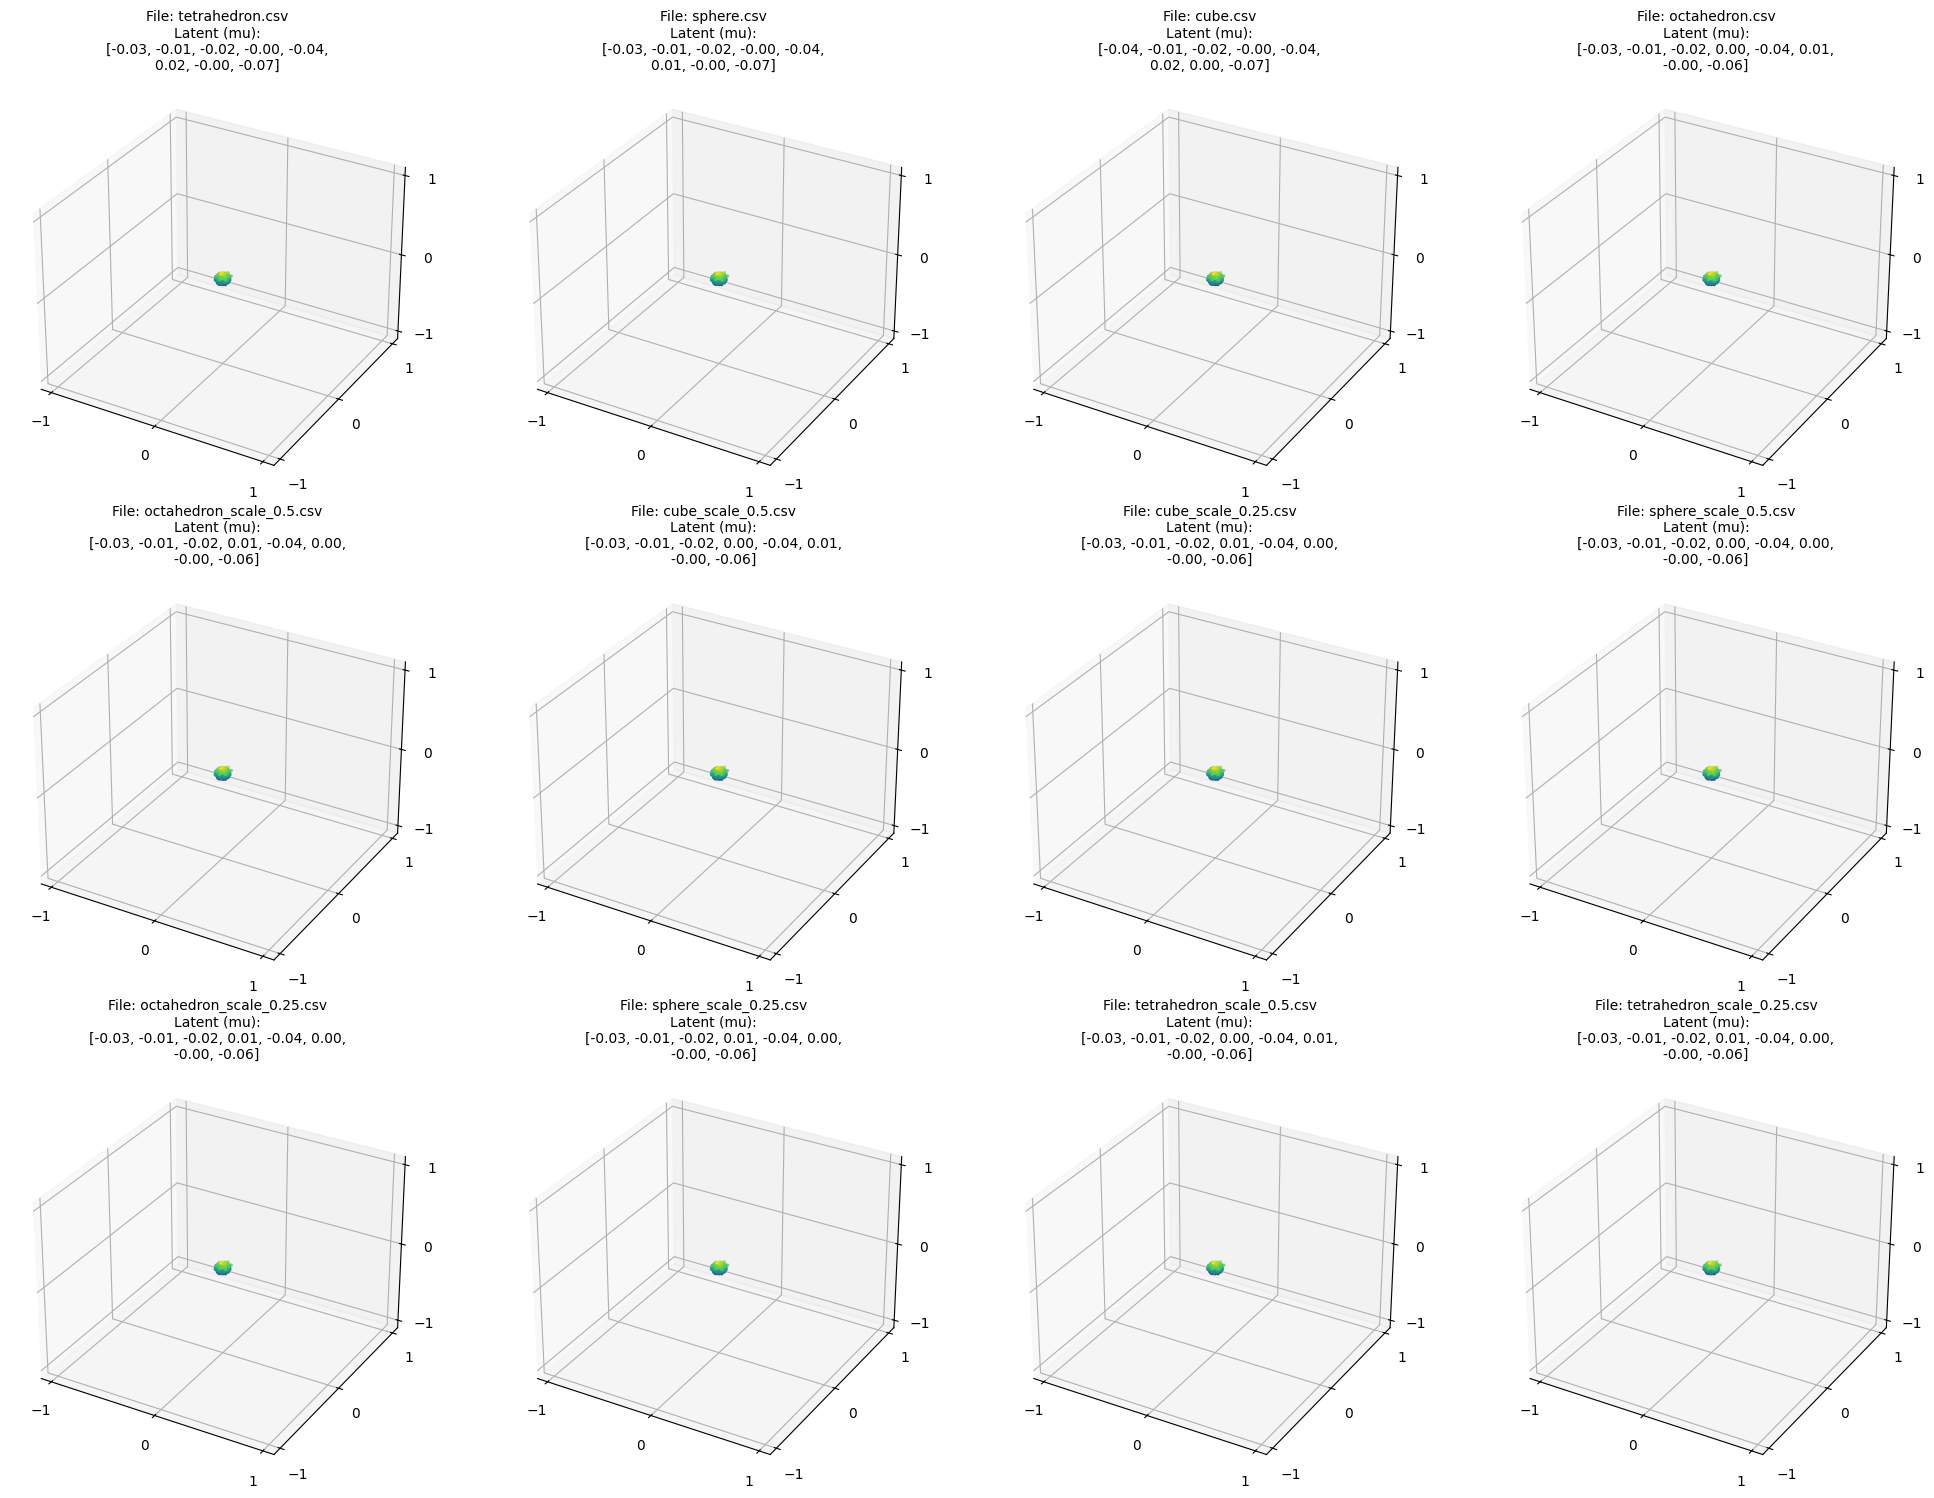

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import textwrap

# ★ 引数に num_points を追加
def visualize_trained_reconstructions(vae, dataloader, num_points=4096):
    """
    データローダーに含まれるすべてのデータの潜在変数を取得し、再構成して一覧表示する
    """
    vae.eval()
    device = next(vae.parameters()).device
    
    all_reconstructed = []
    all_mu = []
    all_filenames = []
    
    # 1. データローダーから全データを取得
    with torch.no_grad():
        for batch in dataloader:
            # 現在のカスタムデータセットの戻り値に対応
            # ★ 修正: points_list として受け取る
            filenames, points_list, ext_features1_list, targets1_list, ext_features2_list, targets2_list = batch
            
            # ★ 修正: リスト内の各点群から先頭の num_points 分を切り出して結合(stack)し、GPUへ送る
            points = torch.stack([pts[:, :num_points] for pts in points_list], dim=0).to(device)
            
            # エンコーダで実際の潜在変数(mu)を取得
            mu, _ = vae.encoder(points)
            # そのmuを使ってデコード（再構成）
            reconstructed_points = vae.decoder(mu).cpu().numpy()
            
            all_reconstructed.append(reconstructed_points)
            all_mu.append(mu.cpu().numpy())
            all_filenames.extend(filenames)
            
    # リストを結合して1つのNumPy配列にする
    reconstructed_points = np.concatenate(all_reconstructed, axis=0)
    mu_np = np.concatenate(all_mu, axis=0)
    num_samples = reconstructed_points.shape[0]

    # グリッドのサイズを自動計算 (データ数に応じて正方形に近い配置にする)
    cols = int(np.ceil(np.sqrt(num_samples)))
    rows = int(np.ceil(num_samples / cols))

    # サブプロットの数に合わせて全体の図のサイズを調整
    fig = plt.figure(figsize=(cols * 5, rows * 5))
    
    for i in range(num_samples):
        ax = fig.add_subplot(rows, cols, i + 1, projection="3d")
        points = reconstructed_points[i]
        filename = all_filenames[i]
        
        # 3D散布図 (c=points[:, 2] で高さ（Z軸）に応じて色付け)
        sc = ax.scatter(points[:, 0], points[:, 1], points[:, 2], 
                        s=2, c=points[:, 2], cmap='viridis', alpha=0.6)
        
        # 潜在変数を文字列化
        mu_str = ", ".join([f"{val:.2f}" for val in mu_np[i]])
        # 次元数(z_dim)が大きいとタイトルが横に長くなりすぎるため、自動で改行する
        wrapped_mu_str = "\n".join(textwrap.wrap(f"[{mu_str}]", width=40))
        
        # タイトルにファイル名と潜在変数を表示
        ax.set_title(f"File: {filename}\nLatent (mu):\n{wrapped_mu_str}", fontsize=10)
        
        # 軸の範囲設定（データが-1〜1の範囲なので少し広めに設定）
        ax.set_xlim([-1.1, 1.1])
        ax.set_ylim([-1.1, 1.1])
        ax.set_zlim([-1.1, 1.1])
#        ax.set_xlim([0, 1])
#        ax.set_ylim([0, 1])
#        ax.set_zlim([0, 1])

        # メモリを -1, 0, 1 に設定
        ticks = [-1.0, 0.0, 1.0]
#        ticks = [0, 0.5, 1.0]
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_zticks(ticks)

    plt.tight_layout()
    plt.show()

# --- 実行 ---
# 学習時とは違い、全データを漏れなく抽出する eval_dataloader を渡します
print(f"Visualizing all {len(dataset)} reconstructed point clouds...")
# ★ 引数に num_points を追加
visualize_trained_reconstructions(vae, eval_dataloader, num_points=num_points)

# Latent Viz

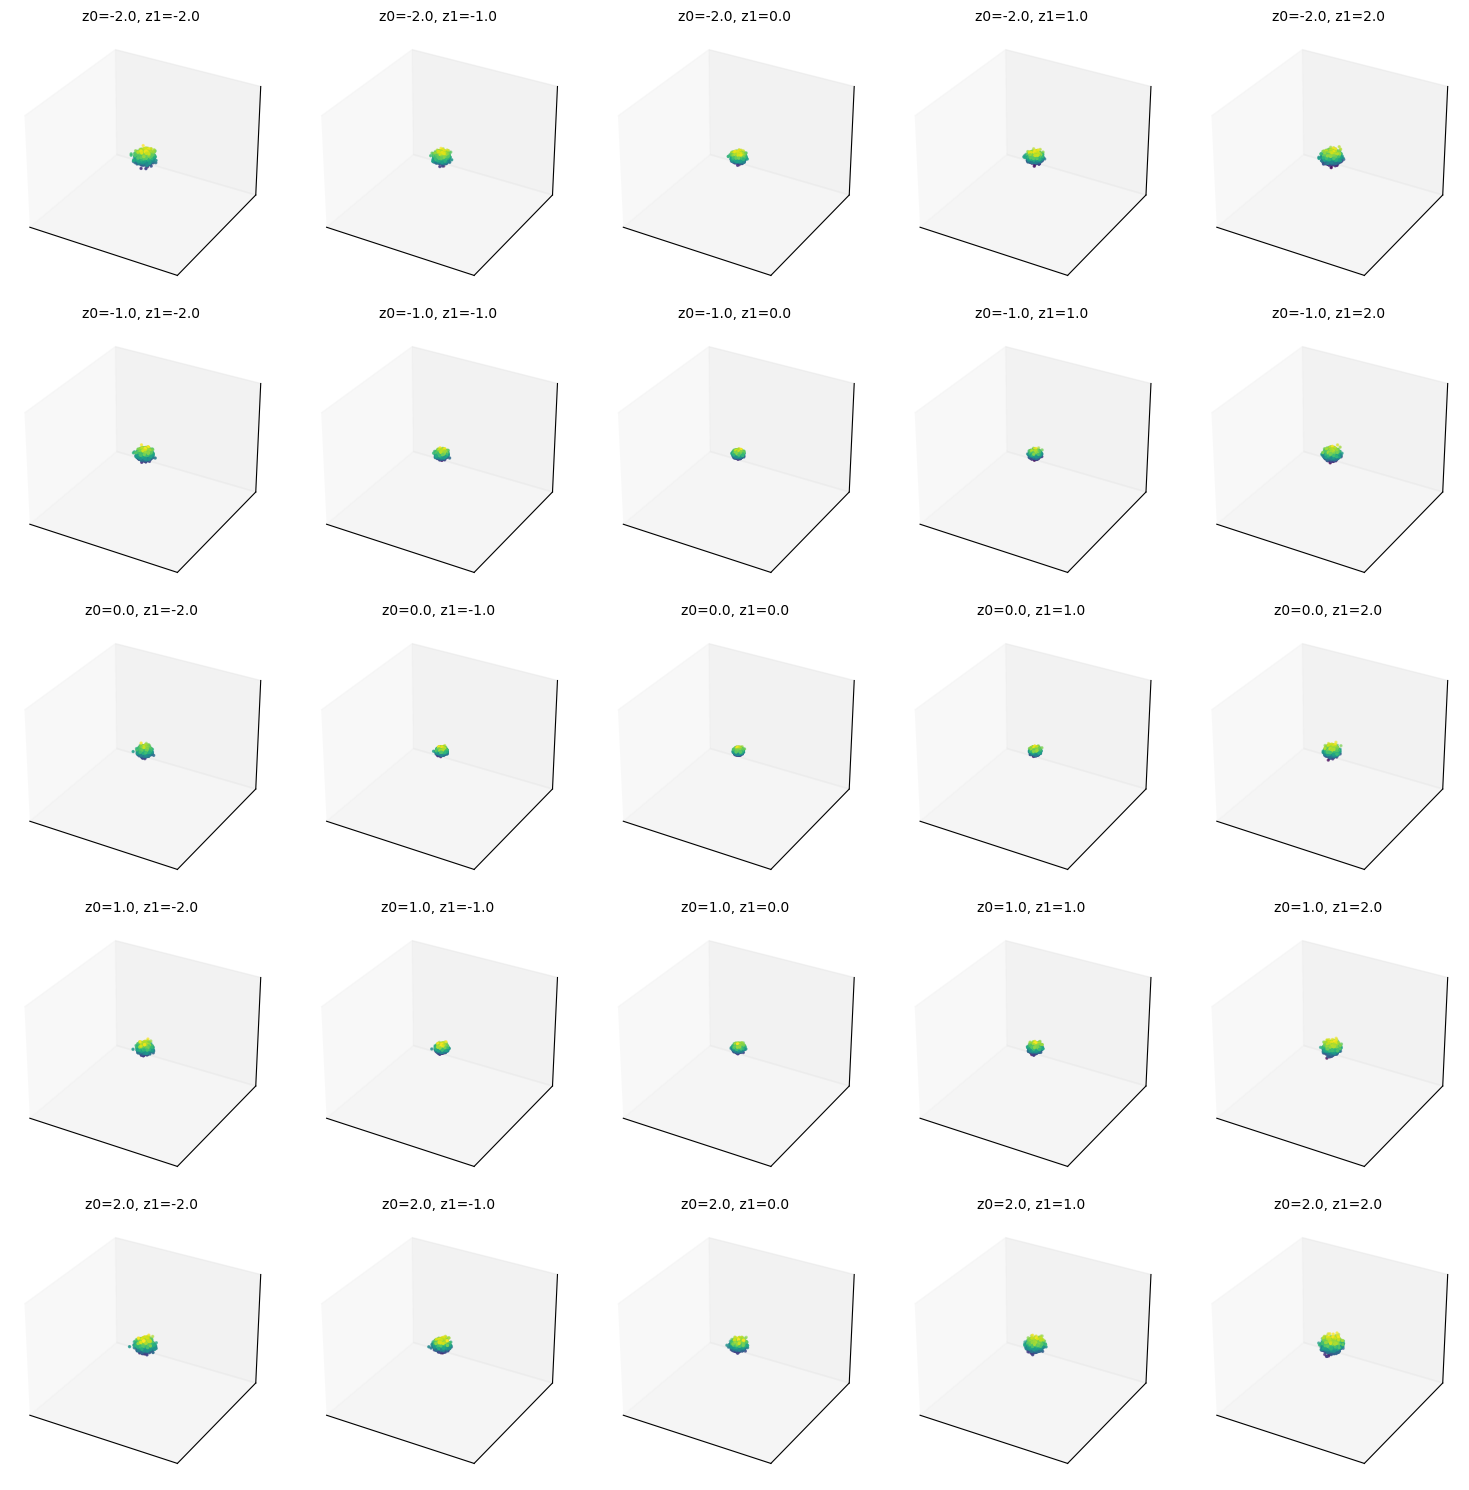

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_latent_space(decoder, z_dim, idx1, idx2, range1=[-2, 2], range2=[-2, 2], steps=5):
    """
    高次元潜在空間のうち、指定した2つの次元(idx1, idx2)だけを動かし、
    残りの次元をすべて0に固定して点群を生成・可視化する関数。
    """
    # モデルが現在どのデバイスにあるか取得
    device = next(decoder.parameters()).device
    
    # 指定された範囲とステップ数で値を生成
    z1_values = np.linspace(range1[0], range1[1], steps)
    z2_values = np.linspace(range2[0], range2[1], steps)

    fig = plt.figure(figsize=(15, 15))
    plot_index = 1
    
    for z1 in z1_values:
        for z2 in z2_values:
            # 1. z_dim次元の「すべてゼロ」のベクトルを作成 (ここで他の次元が0に固定される)
            z = torch.zeros((1, z_dim), dtype=torch.float32).to(device)
            
            # 2. ユーザーが指定した2つの次元(インデックス)にのみ、値を代入する
            z[0, idx1] = z1
            z[0, idx2] = z2

            # デコーダで点群を生成
            with torch.no_grad():
                generated_points = decoder(z).squeeze().cpu().numpy()

            # 3Dプロットの作成
            ax = fig.add_subplot(steps, steps, plot_index, projection="3d")
            sc = ax.scatter(generated_points[:, 0], generated_points[:, 1], generated_points[:, 2], 
                            s=2, c=generated_points[:, 2], cmap='viridis')

            # タイトルに「どの次元を動かしているか」を表示
            ax.set_title(f"z{idx1}={z1:.1f}, z{idx2}={z2:.1f}", fontsize=10)
            
            # 軸の範囲と目盛りの非表示
            ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
            ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

            plot_index += 1

    plt.tight_layout()
    plt.show()

# ==========================================
# --- 実行部分 ---
# ==========================================
vae.eval() 

# メインコードからz_dimを自動取得（手入力を防ぐため）
current_z_dim = vae.encoder.z_dim

# 例：16次元のうち、インデックス「0」と「1」の軸を動かす
visualize_latent_space(
    decoder=vae.decoder,
    z_dim=current_z_dim, # 現在のモデルの次元数を自動で渡す
    idx1=0,              # 動かしたい1つ目の次元のインデックス (0から始まります)
    idx2=1,              # 動かしたい2つ目の次元のインデックス
    range1=[-2, 2],      # idx1の可動範囲
    range2=[-2, 2],      # idx2の可動範囲
    steps=5              # 5x5のグリッドで表示
)

# Device Check

In [29]:
check_environment()


# --- ユニット節約のための自動切断処理 ---
if torch.cuda.is_available():
    print("GPU環境を検知しました。ユニット消費を抑えるため、ランタイムを解除します。")
    try:
        from google.colab import runtime
        runtime.unassign()
    except ImportError:
        print("Google Colab環境外のため、切断をスキップしました。")
else:
    print("CPU環境のため、接続を維持します。引き続きコードの編集が可能です。")

--- 💡 Execution Environment: CPU ---
CPU環境のため、接続を維持します。引き続きコードの編集が可能です。
